# DCS with single-$L$ MF34 uncertainty band — JEFF-4.0 @ 2.8 MeV vs JENDL-5 @ 1.571 MeV

Two-panel figure for Fe-56 elastic scattering:

| Panel | Library  | Energy     | MF34 band from |
|-------|----------|------------|----------------|
| Left  | JEFF-4.0 | 2.800 MeV  | $L=6$          |
| Right | JENDL-5  | 1.571 MeV  | $L=1$          |

In each panel the **curve** is the full Legendre reconstruction (all $a_L$,
$L \geq 1$) with $c_0$ fitted to EXFOR; the **shaded band** is the dσ/dΩ
uncertainty obtained by propagating *only* the diagonal MF34 covariance entry
for a single Legendre order:

$$\sigma_{d\sigma/d\Omega}(\mu) \;=\; c_0\,(2L+1)\,|P_L(\mu)|\,\sqrt{\mathrm{Var}(a_L)}.$$

EXFOR experimental points in the matching energy bin are overlaid with a
single marker style and a single legend entry.


## 1. Configuration

In [1]:
# Files
JEFF_FILE      = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt"
JENDL_FILE     = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/260560.jendl5"
EXFOR_DB_PATH  = "/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db"
TARGET_ZAIDS   = [26056, 26000]
SUPPLEMENTARY_JSON_FILES = [
    "/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json",
]
EXCLUDE_EXPERIMENTS = ["32246002"]

# Physics
MT_NUMBER = 2
M_PROJ_U  = 1.008665
M_TARG_U  = 55.93494

# EXFOR filter (matches library_comparison.ipynb)
MIN_STAT_RELATIVE_UNCERTAINTY = 0.01
UNCERTAINTY_FLOOR_STRATEGY    = "bin_median"
MAX_EXP_WEIGHT_FRAC_BIN       = 0.8

# EXFOR anchor subentries for c0 fitting (matches library_comparison.ipynb).
# Smith for E >= 2.5 MeV, Kinney for E < 2.5 MeV.
KINNEY_SUBENTRY      = "10571002"
SMITH_SUBENTRY       = "10886002"
ENERGY_THRESHOLD_MEV = 2.5

# Panels: (library_name, ENDF file, target E [MeV], L for MF34 band, color)
PANELS = [
    dict(name="JEFF-4.0", file=JEFF_FILE,  energy_mev=2.800,
         L_band=6, color="#0173B2"),
    dict(name="JENDL-5",  file=JENDL_FILE, energy_mev=1.571,
         L_band=1, color="#029E73"),
]
EXFOR_COLOR = "black"

# Number of sigma for the band
N_SIGMA = 1

# Plot fonts (thesis-publication readable)
plt_fontsizes = dict(
    axes_label=20, tick_label=18, legend=18,
    subplot_title=20, suptitle=20,
)


## 2. Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from numpy.polynomial.legendre import legval
from scipy.special import legendre

_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

import kika
from kika.endf import read_endf
from kika.exfor import read_all_exfor
import kika.exfor as exfor

from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    filter_exfor_with_energy_bin,
)
from scripts.resample_AD import sample_legendre_coefficients

exfor.configure(db_path=EXFOR_DB_PATH)
print("Imports OK")


Imports OK


## 3. Helpers

Copied / adapted from `library_comparison.ipynb` so the notebook is
self-contained. The only new piece is `propagate_mf34_single_L`, which
keeps a single diagonal entry of the MF34 covariance.


In [3]:
def load_endf_raw(filepath, label):
    print(f"  Loading {label} from {filepath} ...")
    endf_obj = read_endf(filepath)
    mt_section = endf_obj.get_file(4).sections[MT_NUMBER]
    energies_ev = np.array(mt_section.legendre_energies)
    mf34 = None
    try:
        mf34 = endf_obj.mf[34].mt[MT_NUMBER].to_ang_covmat()
        print(f"    MF34: {mf34.num_matrices} matrices")
    except Exception as exc:
        print(f"    MF34: not available ({exc})")
    return dict(label=label, endf=endf_obj, mf34=mf34,
                energies_mev=energies_ev / 1e6, mt_section=mt_section)


def select_energy_from_endf(raw_case, target_energy_mev):
    energies_mev = raw_case["energies_mev"]
    target_idx = int(np.argmin(np.abs(energies_mev - target_energy_mev)))
    closest_mev = energies_mev[target_idx]
    endf_coeffs = np.array(raw_case["mt_section"].legendre_coefficients[target_idx])
    L_max = len(endf_coeffs)
    bin_lower = (energies_mev[target_idx - 1] + closest_mev) / 2 if target_idx > 0 else 0.0
    bin_upper = ((closest_mev + energies_mev[target_idx + 1]) / 2
                 if target_idx < len(energies_mev) - 1 else float("inf"))
    print(f"  {raw_case['label']}: requested {target_energy_mev} MeV -> closest {closest_mev:.4f} MeV, "
          f"L_max={L_max}, bin=[{bin_lower:.4f}, {bin_upper:.4f}]")
    return dict(**raw_case, L_max=L_max, endf_coeffs=endf_coeffs,
                target_idx=target_idx, closest_energy_mev=closest_mev,
                bin_lower=bin_lower, bin_upper=bin_upper)


def attach_total_uncertainty(df):
    if df is None or df.empty:
        return df
    sigma_stat = df["unc"].to_numpy(dtype=float)
    if "sigma_sys_relative" in df.columns:
        sigma_sys_rel = df["sigma_sys_relative"].to_numpy(dtype=float)
        sigma_sys_abs = sigma_sys_rel * np.abs(df["value"].to_numpy(dtype=float))
    else:
        sigma_sys_abs = np.zeros_like(sigma_stat)
    df = df.copy()
    df["unc_total"] = np.sqrt(sigma_stat ** 2 + sigma_sys_abs ** 2)
    return df


def filter_exfor_in_bin(case_data, exfor_cache, sorted_exfor_energies,
                       post_filter_subentry=None):
    df, exp_info, kw, _, _ = filter_exfor_with_energy_bin(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        bin_lower_mev=case_data["bin_lower"],
        bin_upper_mev=case_data["bin_upper"],
        target_energy_mev=case_data["closest_energy_mev"],
        m_proj_u=M_PROJ_U, m_targ_u=M_TARG_U,
        dedupe_per_experiment=True,
        exclude_experiments=EXCLUDE_EXPERIMENTS,
        min_relative_uncertainty=MIN_STAT_RELATIVE_UNCERTAINTY,
        unc_floor_strategy=UNCERTAINTY_FLOOR_STRATEGY,
        normalize_by_n_points=True,
        max_experiment_weight_fraction=MAX_EXP_WEIGHT_FRAC_BIN,
    )
    if not df.empty and "experiment_id" not in df.columns:
        df["experiment_id"] = df["entry"] + "/" + df["subentry"]
    if post_filter_subentry is not None and not df.empty:
        entry_str, sub_str = post_filter_subentry[:5], post_filter_subentry[5:]
        mask = (df["entry"] == entry_str) & (df["subentry"] == sub_str)
        if mask.any():
            df = df[mask].reset_index(drop=True)
            kw = kw[mask.values] if kw is not None else None
            exp_info = [e for e in exp_info
                        if e.get("entry") == entry_str and e.get("subentry") == sub_str]
        else:
            print(f"    WARNING: anchor subentry {post_filter_subentry} not in bin")
    df = attach_total_uncertainty(df)
    return df, exp_info, kw


def fit_c0_from_exfor(case_data, exfor_df, kernel_weights):
    "Hybrid c0 fit: same convention as `library_comparison.ipynb`."
    degree = case_data["L_max"]
    coef_df, fit_info = sample_legendre_coefficients(
        df=exfor_df, value_col="value", unc_col="unc", mu_col="mu",
        degree=degree, n_samples=1,
        external_weights=kernel_weights,
        ridge_lambda=1e-6, rescale_unc_by_chi2=True,
    )
    c0 = float(coef_df["c0"].values[0])
    chi2_red = float(fit_info["chi2_red"])
    print(f"  c0 (EXFOR) = {c0:.6f} b/sr,  chi2_red = {chi2_red:.2f},  N = {len(exfor_df)}")
    return c0


def hybrid_dcs(c0, endf_coeffs, mu_array):
    "Full DCS = c0 * [1 + sum_{L>=1} (2L+1) a_L P_L(mu)]."
    hybrid_coeffs = [c0]
    for l in range(1, len(endf_coeffs) + 1):
        hybrid_coeffs.append(c0 * (2 * l + 1) * float(endf_coeffs[l - 1]))
    return legval(mu_array, hybrid_coeffs)


def propagate_mf34_single_L(mf34_covmat, e_mev, mu_array, endf_coeffs, c0, L_keep):
    "Sandwich propagation reduced to a single MF34 diagonal entry (L_keep, L_keep)."
    if mf34_covmat is None:
        return np.zeros(len(mu_array)), 0.0
    L_max = len(endf_coeffs)
    if not (1 <= L_keep <= L_max):
        return np.zeros(len(mu_array)), 0.0
    e_search = e_mev * 1e6 if getattr(mf34_covmat, "energy_unit", "eV") == "eV" else e_mev
    cov_LL = 0.0
    for idx in range(len(mf34_covmat.matrices)):
        l_r = mf34_covmat.l_rows[idx]
        l_c = mf34_covmat.l_cols[idx]
        if l_r != L_keep or l_c != L_keep:
            continue
        grid = np.array(mf34_covmat.energy_grids[idx])
        mat = mf34_covmat.matrices[idx]
        k = np.searchsorted(grid, e_search, side="right") - 1
        k = np.clip(k, 0, mat.shape[0] - 1)
        cov_val = mat[k, k]
        if mf34_covmat.is_relative[idx]:
            cov_val *= endf_coeffs[L_keep - 1] * endf_coeffs[L_keep - 1]
        cov_LL = float(cov_val)
        break
    if cov_LL <= 0:
        return np.zeros(len(mu_array)), 0.0
    delta_a = np.sqrt(cov_LL)
    pl = legendre(L_keep)(mu_array)
    return c0 * (2 * L_keep + 1) * np.abs(pl) * delta_a, delta_a


## 4. Load ENDF files and EXFOR database

In [4]:
print("Loading ENDF files ...")
endf_raw = {p["name"]: load_endf_raw(p["file"], p["name"]) for p in PANELS}

print("\nLoading EXFOR ...")
exfor_dict = read_all_exfor(
    target=TARGET_ZAIDS, mt=MT_NUMBER, source="database",
    group_by_energy=False,
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)
exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
    list(exfor_dict.values()), exclude_experiments=EXCLUDE_EXPERIMENTS,
)
print(f"  Datasets        : {len(exfor_dict)}")
print(f"  Unique energies : {len(sorted_exfor_energies)}")


Loading ENDF files ...
  Loading JEFF-4.0 from /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt ...


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [6, 8, 10, 12, 14]. Only parsing: [1, 2, 3, 4, 33, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


    MF34: 21 matrices
  Loading JENDL-5 from /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/260560.jendl5 ...


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [6, 8]. Only parsing: [1, 2, 3, 4, 33, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


    MF34: 1 matrices

Loading EXFOR ...
  [uncertainty_manifest] 10384016 (default→total): σ_sys capped at σ_total on 2/17 rows; σ_stat floored at 1% of |y| on 1/17 rows.
  [uncertainty_manifest] 10556006 (default→total): σ_sys capped at σ_total on 14/14 rows; σ_stat floored at 1% of |y| on 8/14 rows.
  [uncertainty_manifest] 10571002 (manifest): σ_sys capped at σ_total on 350/16008 rows; σ_stat floored at 1% of |y| on 190/16008 rows.
  [uncertainty_manifest] 10633008 (default→total): σ_sys capped at σ_total on 14/29 rows; σ_stat floored at 1% of |y| on 9/29 rows.
  [uncertainty_manifest] 10886002 (manifest): σ_sys capped at σ_total on 20/490 rows; σ_stat floored at 1% of |y| on 13/490 rows.
  [uncertainty_manifest] 11220013 (default→total): σ_sys capped at σ_total on 9/30 rows; σ_stat floored at 1% of |y| on 4/30 rows.
  [uncertainty_manifest] 11316003 (default→total): σ_sys capped at σ_total on 2/55 rows; σ_stat floored at 1% of |y| on 2/55 rows.
  [uncertainty_manifest] 11396011 (de

## 5. Build each panel — select energy, filter EXFOR, fit $c_0$, propagate band


In [5]:
mu_grid = np.linspace(-1, 1, 400)
panel_data = []

for p in PANELS:
    print(f"\n=== {p['name']} at {p['energy_mev']} MeV, MF34 L={p['L_band']} band ===")
    raw = endf_raw[p["name"]]
    case = select_energy_from_endf(raw, p["energy_mev"])

    anchor = (KINNEY_SUBENTRY if case["closest_energy_mev"] < ENERGY_THRESHOLD_MEV
              else SMITH_SUBENTRY)
    print(f"  c0-fit anchor subentry: {anchor}")

    # All in-bin EXFOR for plotting (no anchor restriction)
    exfor_all, _, _ = filter_exfor_in_bin(case, exfor_cache, sorted_exfor_energies,
                                          post_filter_subentry=None)
    # Anchor-restricted EXFOR for the c0 fit (same convention as the source notebook)
    exfor_fit, _, kw_fit = filter_exfor_in_bin(case, exfor_cache, sorted_exfor_energies,
                                                post_filter_subentry=anchor)
    print(f"  EXFOR (all)    : {len(exfor_all)} pts across "
          f"{exfor_all['experiment_id'].nunique() if not exfor_all.empty else 0} experiments")
    print(f"  EXFOR (anchor) : {len(exfor_fit)} pts")

    c0 = fit_c0_from_exfor(case, exfor_fit, kw_fit)
    dcs = hybrid_dcs(c0, case["endf_coeffs"], mu_grid)
    band, delta_a = propagate_mf34_single_L(
        case["mf34"], case["closest_energy_mev"],
        mu_grid, case["endf_coeffs"], c0, p["L_band"],
    )
    a_L = float(case["endf_coeffs"][p["L_band"] - 1])
    rel = (delta_a / abs(a_L) * 100) if a_L else float("nan")
    print(f"  a_{p['L_band']} = {a_L:+.5f},  delta_a_{p['L_band']} = {delta_a:.5f}  "
          f"({rel:.1f}% rel)")
    print(f"  max band/DCS ratio = {np.max(band / np.maximum(dcs, 1e-12)) * 100:.1f}%")

    panel_data.append(dict(
        spec=p, case=case, exfor_all=exfor_all,
        c0=c0, dcs=dcs, band=band, delta_a=delta_a,
    ))



=== JEFF-4.0 at 2.8 MeV, MF34 L=6 band ===
  JEFF-4.0: requested 2.8 MeV -> closest 2.8000 MeV, L_max=6, bin=[2.7750, 2.8250]
  c0-fit anchor subentry: 10886002
  EXFOR (all)    : 43 pts across 6 experiments
  EXFOR (anchor) : 10 pts
  c0 (EXFOR) = 0.181220 b/sr,  chi2_red = 0.01,  N = 10
  a_6 = +0.00297,  delta_a_6 = 0.05575  (1878.8% rel)
  max band/DCS ratio = 118.9%

=== JENDL-5 at 1.571 MeV, MF34 L=1 band ===
  JENDL-5: requested 1.571 MeV -> closest 1.5710 MeV, L_max=6, bin=[1.5705, 1.5720]
  c0-fit anchor subentry: 10571002
  EXFOR (all)    : 19 pts across 3 experiments
  EXFOR (anchor) : 8 pts
  c0 (EXFOR) = 0.173147 b/sr,  chi2_red = 1.03,  N = 8
  a_1 = +0.48854,  delta_a_1 = 0.12555  (25.7% rel)
  max band/DCS ratio = 60.2%


## 6. Figure

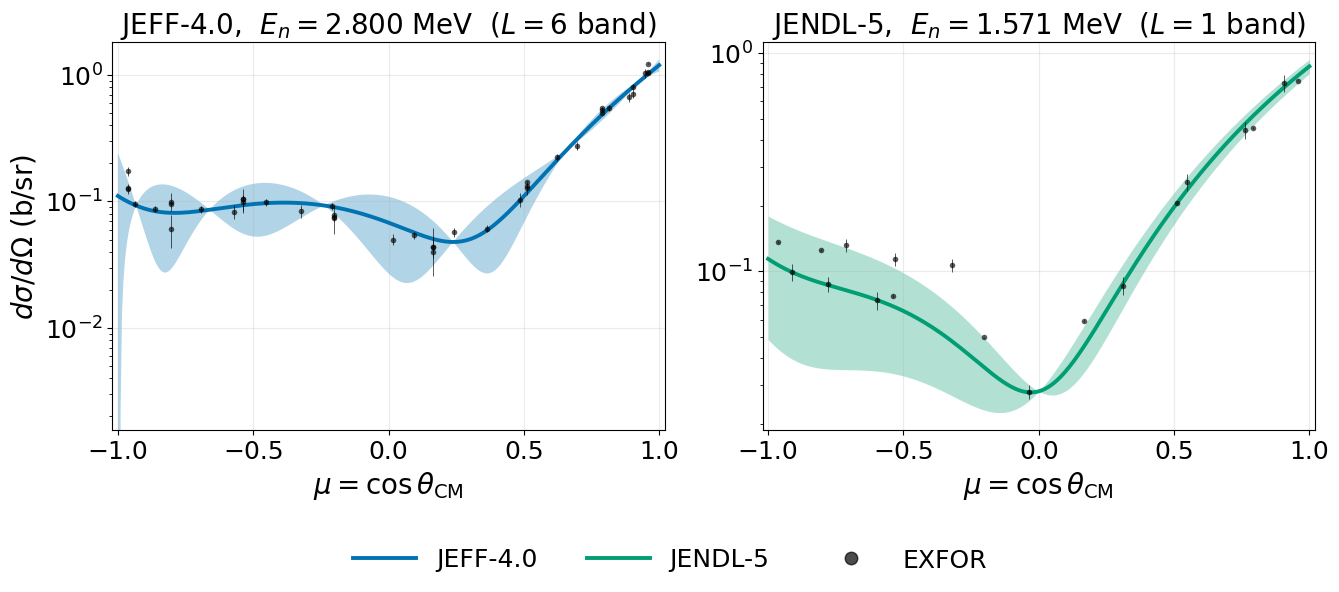

In [6]:
FS = plt_fontsizes
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0))

for ax, pd_ in zip(axes, panel_data):
    spec = pd_["spec"]
    case = pd_["case"]
    df_all = pd_["exfor_all"]
    color = spec["color"]

    # DCS curve
    ax.plot(mu_grid, pd_["dcs"], color=color, lw=2.8, label=spec["name"])
    # Single-L MF34 band
    ax.fill_between(
        mu_grid,
        pd_["dcs"] - N_SIGMA * pd_["band"],
        pd_["dcs"] + N_SIGMA * pd_["band"],
        color=color, alpha=0.30, linewidth=0,
    )

    # EXFOR scatter -- unified, one marker for all points
    if not df_all.empty:
        ax.errorbar(
            df_all["mu"].to_numpy(), df_all["value"].to_numpy(),
            yerr=df_all["unc_total"].to_numpy(),
            fmt="o", color=EXFOR_COLOR, markersize=4,
            alpha=0.65, capsize=2, elinewidth=0.7, markeredgewidth=0,
            linestyle="none", label="EXFOR",
        )

    ax.set_xlabel(r"$\mu = \cos\theta_{\rm CM}$", fontsize=FS["axes_label"])
    ax.set_title(
        rf"{spec['name']},  $E_n = {case['closest_energy_mev']:.3f}$ MeV"
        rf"  ($L={spec['L_band']}$ band)",
        fontsize=FS["subplot_title"],
    )
    ax.tick_params(axis="both", labelsize=FS["tick_label"])
    ax.set_xlim(-1.02, 1.02)
    ax.grid(True, alpha=0.25)
    ax.set_yscale("log")

axes[0].set_ylabel(r"$d\sigma/d\Omega$ (b/sr)", fontsize=FS["axes_label"])

# Joint legend below the subplots: plain line handles + EXFOR marker.
handles = [
    Line2D([0], [0], color=PANELS[0]["color"], lw=2.8),
    Line2D([0], [0], color=PANELS[1]["color"], lw=2.8),
    Line2D([0], [0], color=EXFOR_COLOR, lw=0, marker="o",
           markersize=9, alpha=0.7),
]
labels = [PANELS[0]["name"], PANELS[1]["name"], "EXFOR"]

fig.tight_layout(rect=[0, 0.13, 1, 1.0])
fig.legend(
    handles, labels,
    loc="lower center", bbox_to_anchor=(0.5, 0.0),
    ncol=3, frameon=False, fontsize=FS["legend"],
    handlelength=2.5,
)
plt.show()


## 7. Save the figure

In [7]:
out_png = Path("jeff_jendl_singleL_band.png")
out_pdf = Path("jeff_jendl_singleL_band.pdf")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
print(f"Saved {out_png.resolve()} and {out_pdf.resolve()}")


Saved /home/MONLEON-JUAN/kika/kika/exfor/tests/jeff_jendl_singleL_band.png and /home/MONLEON-JUAN/kika/kika/exfor/tests/jeff_jendl_singleL_band.pdf
